# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

# Load Dataset

In [3]:
df = pd.read_csv("car_details.csv")

In [5]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [6]:
df.shape

(15411, 14)

Rows = 15411
Columns = 14

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


Categorical variables = car_name,brand,model,seller_type,fuel_type

Numerical Variables = vehical_age,km_driven,mileage,engine,max_power,seats,selling_price

In [8]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


# Data Cleaning

In [9]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

The dataset contains no missing values across all features. Therefore, no imputation techniques were required and the dataset was already complete for further analysis.

In [10]:
df.duplicated().sum()

np.int64(0)

No duplicate records found 

# Exploratory Data Analysis (EDA)

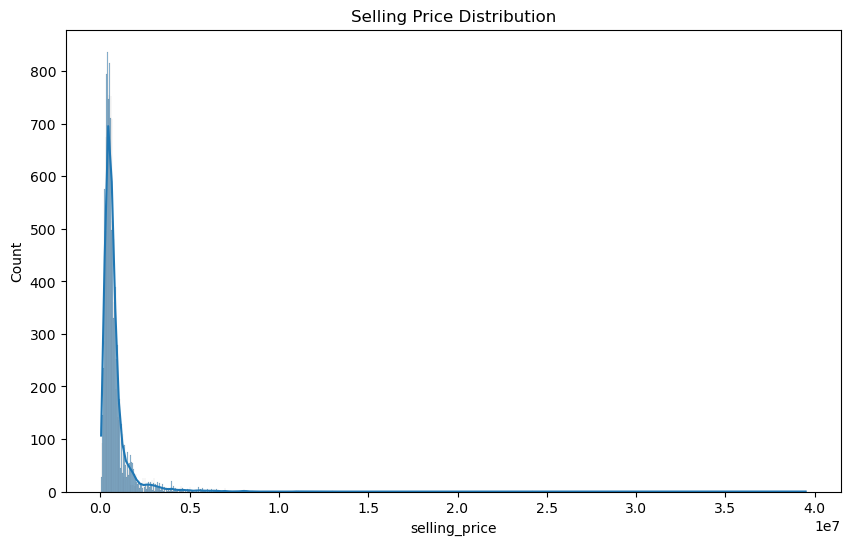

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df["selling_price"],kde=True)
plt.title("Selling Price Distribution")
plt.show()

In [13]:
df["selling_price"].skew()

np.float64(10.047047978435213)

In [15]:
df["log_price"] = np.log1p(df["selling_price"])

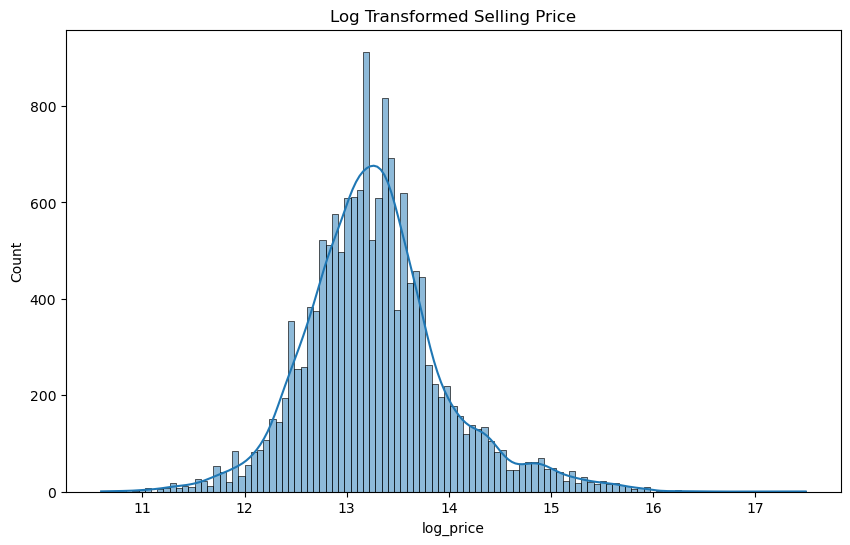

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df["log_price"], kde=True)
plt.title("Log Transformed Selling Price")
plt.show()

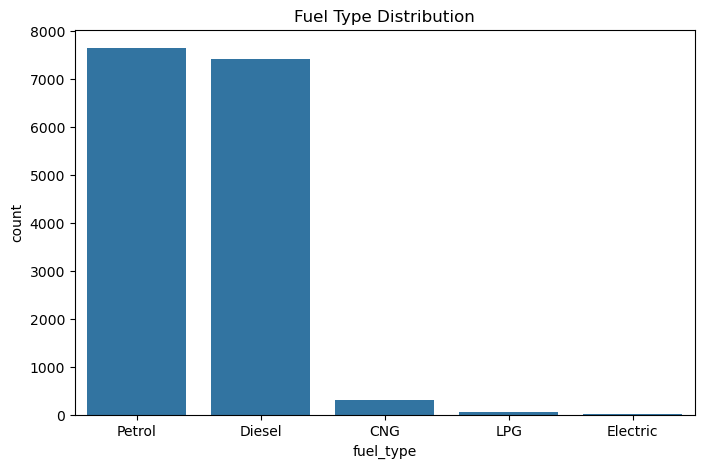

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='fuel_type',
    data =df
)
plt.title("Fuel Type Distribution")
plt.show()

Petrol and diesel vehicles constitute the majority of listings in the dataset, indicating higher market presence compared to CNG, and LPG vehicles.

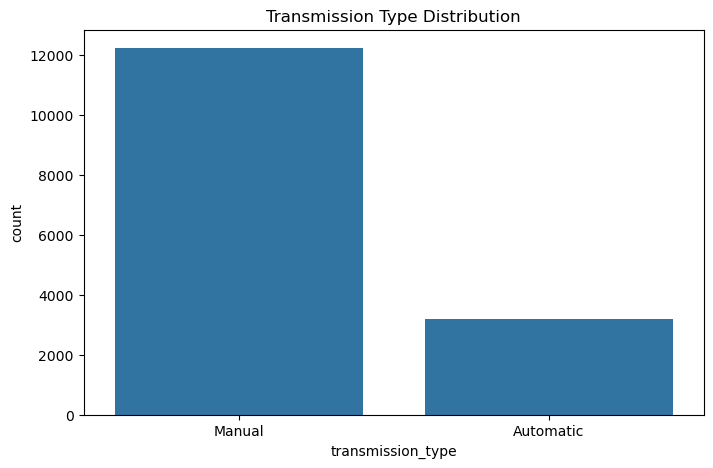

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='transmission_type',
    data =df
)
plt.title("Transmission Type Distribution")
plt.show()

Manual transmission vehicles dominate the used car market, suggesting stronger demand and availability compared to automatic vehicles.

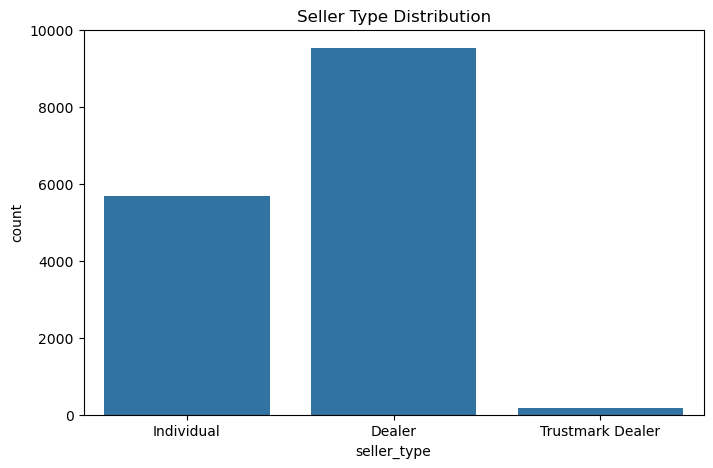

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='seller_type',
    data =df
)
plt.title("Seller Type Distribution")
plt.show()

Dealer sellers account for the majority of vehicle listings,with next on Individual seller type.

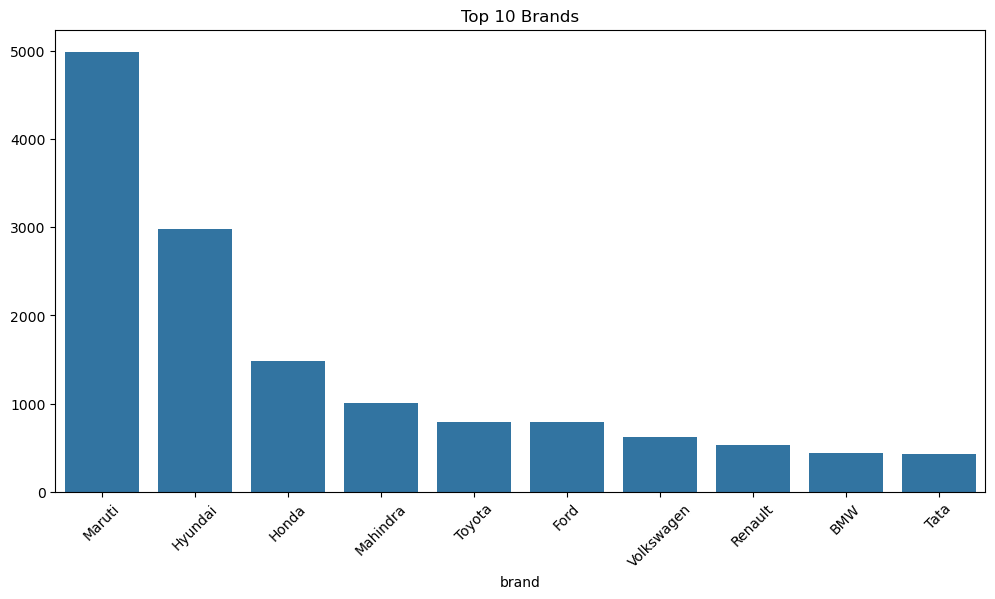

In [22]:
top_brands =df["brand"].value_counts().head(10)
plt.figure(figsize=(12,6))

sns.barplot (
    x= top_brands.index,
    y=top_brands.values
)
plt.xticks(rotation=45)
plt.title("Top 10 Brands")
plt.show()

Maruti accounts for a significant share of the used car market, indicating its popularity and resale activity.

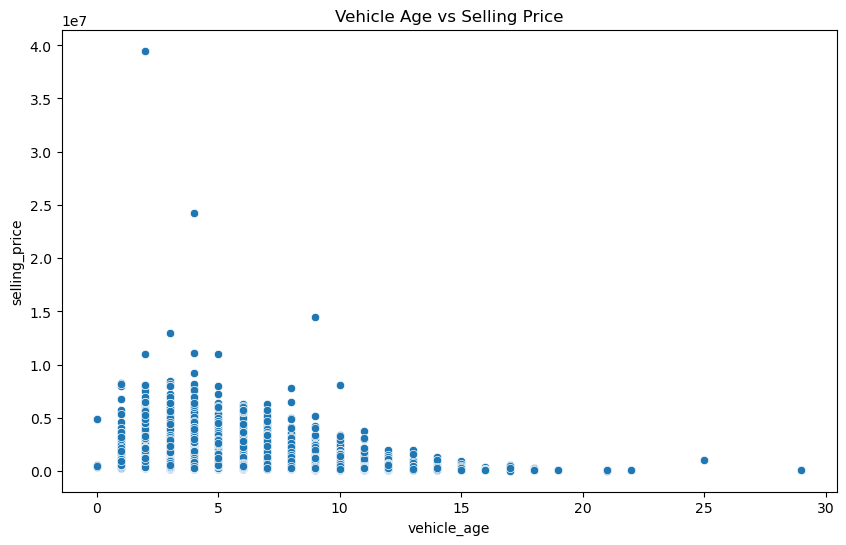

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='vehicle_age',
    y='selling_price',
    data=df
)

plt.title("Vehicle Age vs Selling Price")

plt.show()

Vehicle price generally decreases with increasing age, confirming depreciation as a major factor in resale valuation.

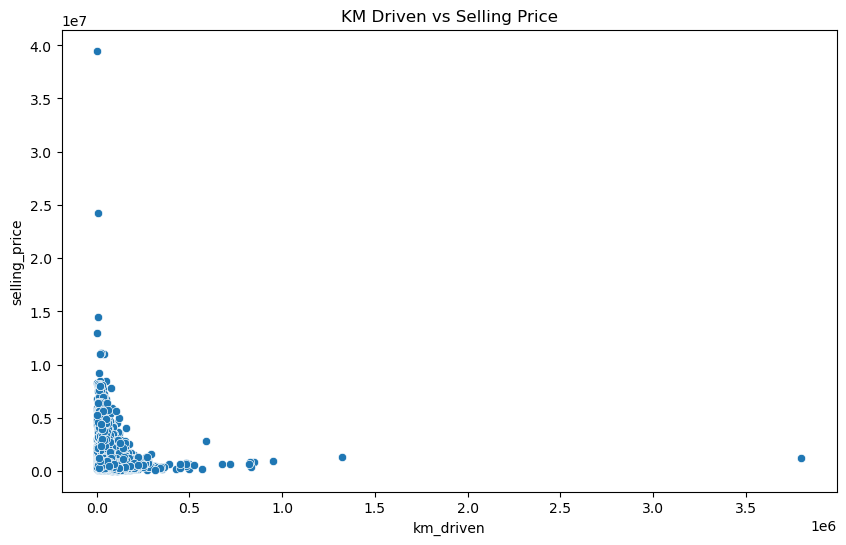

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='km_driven',
    y='selling_price',
    data=df
)

plt.title("KM Driven vs Selling Price")

plt.show()

Cars with lower mileage tend to command higher resale prices, while heavily driven vehicles show reduced market value.

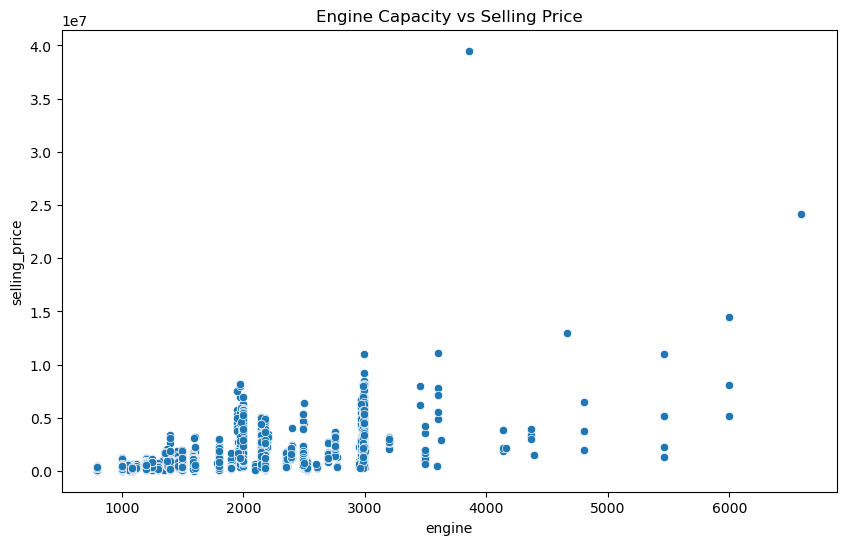

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='engine',
    y='selling_price',
    data=df
)

plt.title("Engine Capacity vs Selling Price")

plt.show()

Engine capacity is an important determinant of vehicle value. Premium vehicles with larger engines tend to achieve substantially higher resale prices compared to economy vehicles.

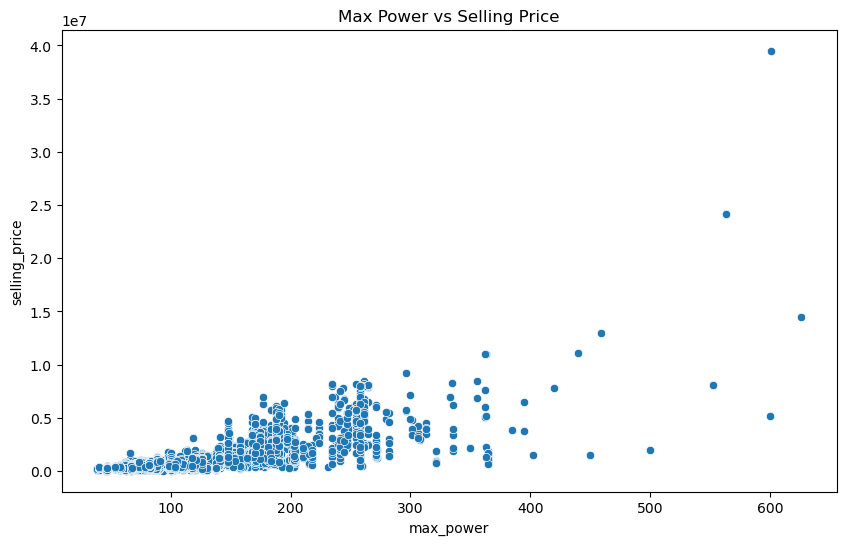

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='max_power',
    y='selling_price',
    data=df
)

plt.title("Max Power vs Selling Price")

plt.show()

Max power is one of the strongest indicators of resale value, as performance-oriented vehicles typically command premium prices in the used car market.

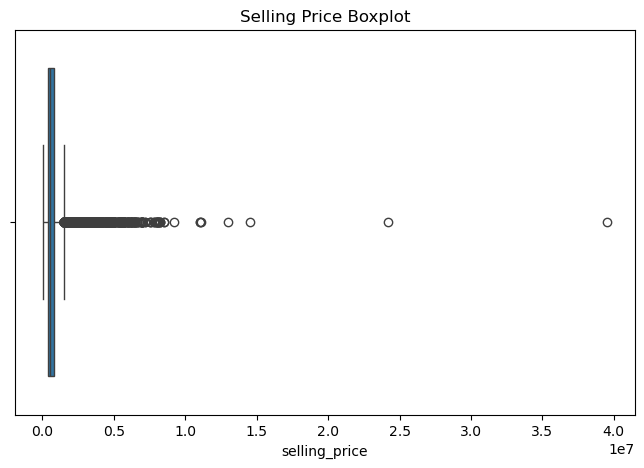

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["selling_price"]
)

plt.title("Selling Price Boxplot")

plt.show()

The used car market is dominated by affordable and mid-range vehicles, while a small number of premium vehicles create significant price variation.

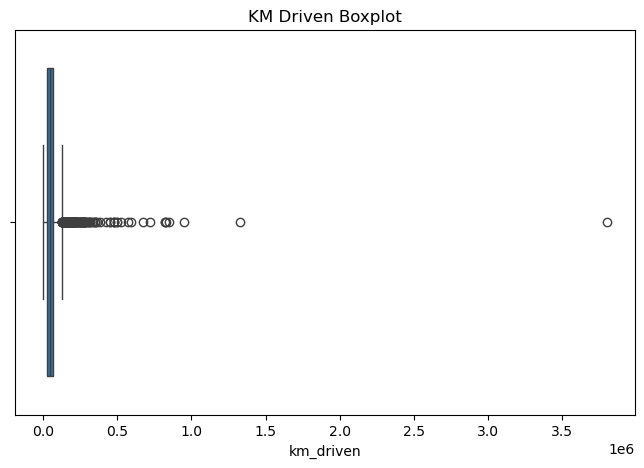

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["km_driven"]
)

plt.title("KM Driven Boxplot")

plt.show()

While most used cars fall within a typical mileage range, a small number of heavily driven vehicles exist and may negatively influence resale value.

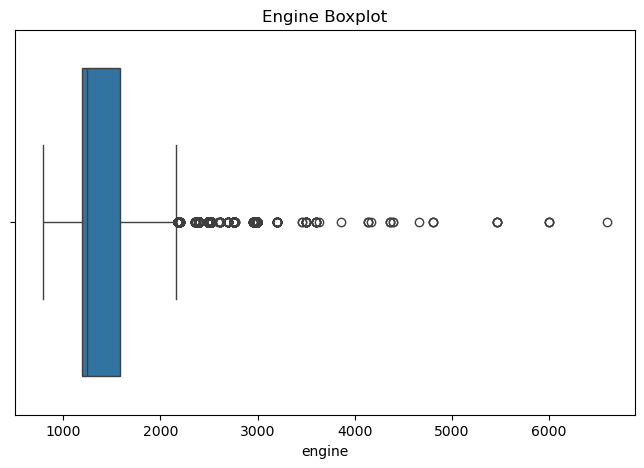

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["engine"]
)

plt.title("Engine Boxplot")

plt.show()

The market is largely composed of economy and mid-sized vehicles, while high-capacity luxury vehicles represent a niche segment with significantly higher valuations.

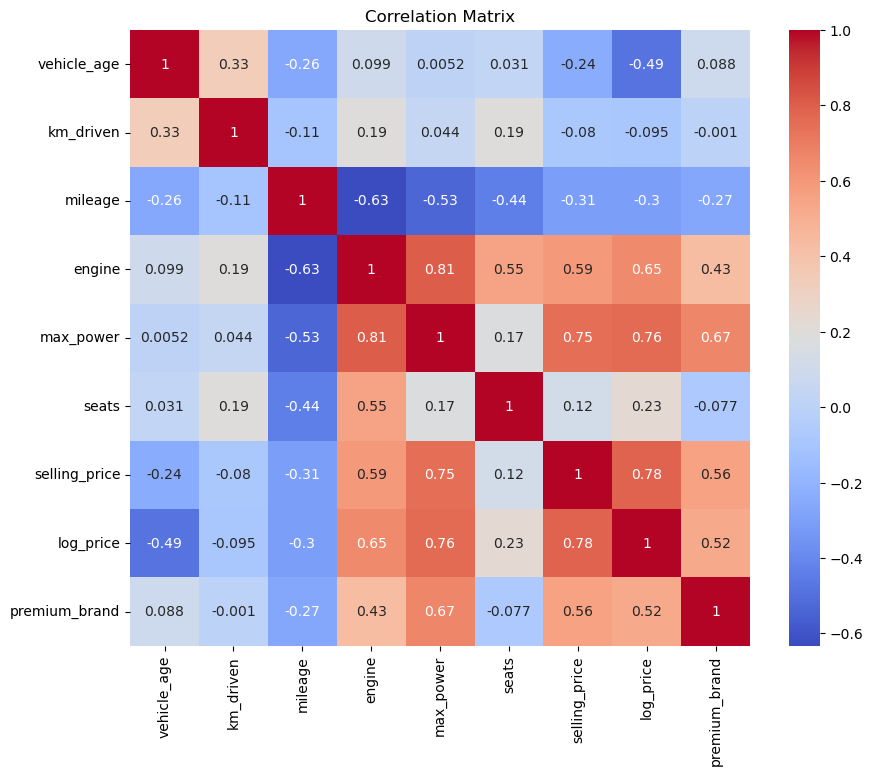

In [46]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Feature Engineering and Feature Selection

In [4]:
df.columns


Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [5]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [6]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

In [7]:
premium_brands = [
    "BMW",
    "Audi",
    "Mercedes-Benz",
    "Jaguar",
    "Volvo",
    "Land Rover"
]

In [8]:
df["premium_brand"] = (
    df["brand"]
    .isin(premium_brands)
    .astype(int)
)

In [9]:
df["premium_brand"].value_counts()

premium_brand
0    14313
1     1098
Name: count, dtype: int64

In [10]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price', 'premium_brand'],
      dtype='object')

In [11]:
df.drop(
    ["car_name","model"],
    axis=1,
    inplace=True
)

In [13]:
df.head()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,premium_brand
0,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000,0
1,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000,0
2,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000,0
3,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000,0
4,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000,0


# Encoding

In [14]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [15]:
df_encoded.shape

(15411, 46)

In [17]:
df_encoded.columns

Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'selling_price', 'premium_brand', 'brand_BMW', 'brand_Bentley',
       'brand_Datsun', 'brand_Ferrari', 'brand_Force', 'brand_Ford',
       'brand_Honda', 'brand_Hyundai', 'brand_ISUZU', 'brand_Isuzu',
       'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land Rover',
       'brand_Lexus', 'brand_MG', 'brand_Mahindra', 'brand_Maruti',
       'brand_Maserati', 'brand_Mercedes-AMG', 'brand_Mercedes-Benz',
       'brand_Mini', 'brand_Nissan', 'brand_Porsche', 'brand_Renault',
       'brand_Rolls-Royce', 'brand_Skoda', 'brand_Tata', 'brand_Toyota',
       'brand_Volkswagen', 'brand_Volvo', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'fuel_type_Diesel',
       'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol',
       'transmission_type_Manual'],
      dtype='object')

In [18]:
df["log_price"] = np.log1p(df["selling_price"])

In [19]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [20]:
X = df_encoded.drop(
    ["selling_price","log_price"],
    axis=1
)

y = df_encoded["log_price"]

In [21]:
X = df_encoded.drop(
    ["selling_price","log_price"],
    axis=1
)

y = df_encoded["log_price"]

# Train Test Split

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size =0.2,
    random_state=42
)

In [25]:
X_train.shape
X_test.shape

(3083, 45)

# Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Model Building

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate_model(y_true, y_pred):
    
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    return mae, rmse, r2


# Model 1 Linear Regression


In [38]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)
lr_pred = lr.predict(
    X_test_scaled
)
lr_mae, lr_rmse, lr_r2 = evaluate_model(
    y_test,
    lr_pred
)

print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R2 :", lr_r2)

MAE : 0.17695261357837186
RMSE : 0.23256188208784404
R2 : 0.8917529599678057


# Model 2 Ridge Regression

In [30]:
from sklearn.linear_model import Ridge
ridge = Ridge(
    alpha=1.0
)

ridge.fit(
    X_train_scaled,
    y_train
)
ridge_pred = ridge.predict(
    X_test_scaled
)
ridge_mae, ridge_rmse, ridge_r2 = evaluate_model(
    y_test,
    ridge_pred
)

print("MAE :", ridge_mae)
print("RMSE :", ridge_rmse)
print("R2 :", ridge_r2)

MAE : 0.17695539296665833
RMSE : 0.23256484917596001
R2 : 0.891750197859484


# Model 3 Lasso Regression


In [31]:
from sklearn.linear_model import Lasso
lasso = Lasso(
    alpha=0.001
)

lasso.fit(
    X_train_scaled,
    y_train
)
lasso_pred = lasso.predict(
    X_test_scaled
)
lasso_mae, lasso_rmse, lasso_r2 = evaluate_model(
    y_test,
    lasso_pred
)

print("MAE :", lasso_mae)
print("RMSE :", lasso_rmse)
print("R2 :", lasso_r2)

MAE : 0.1772671196477321
RMSE : 0.23245076494233044
R2 : 0.8918563752695822


# Model 4 Random Forest

In [34]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)
rf_pred = rf.predict(
    X_test
)
rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_pred
)

print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 :", rf_r2)

MAE : 0.13163087989720246
RMSE : 0.18173333481308326
R2 : 0.9338989809833527


Model 5 XGBoost 

In [35]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 15.1 MB/s eta 0:00:07
   -- ------------------------------------- 6.3/101.7 MB 16.2 MB/s eta 0:00:06
   ---- ----------------------------------- 11.3/101.7 MB 18.5 MB/s eta 0:00:05
   ------ --------------------------------- 16.8/101.7 MB 20.3 MB/s eta 0:00:05
   -------- ------------------------------- 22.3/101.7 MB 21.3 MB/s eta 0:00:04
   ---------- ----------------------------- 27.8/101.7 MB 22.2 MB/s eta 0:00:04
   ------------ --------------------------- 33.0/101.7 MB 22.5 MB/s eta 0:00:04
   --------------- ------------------------ 38.3/101.7 MB 22.7 MB/s eta 0:00:03
   ----------------- ---------------------- 43.8/101.7 MB 22.9 MB/s eta 0:00:03
   ------------------- -------------------- 49.0/101.7 MB 23.1 MB/s eta 0:00:03
   --------------------- ------------------ 54.3/101.7 MB 23.2 MB/s eta 0:00:03
   ----------------------- ---------------- 59.5/10

In [36]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)
xgb_pred = xgb.predict(
    X_test
)
xgb_mae, xgb_rmse, xgb_r2 = evaluate_model(
    y_test,
    xgb_pred
)

print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("R2 :", xgb_r2)

MAE : 0.12741234462710885
RMSE : 0.17230833935966994
R2 : 0.9405774128215457


# Model Comparison Table

In [37]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "XGBoost"
    ],
    
    "MAE":[
        lr_mae,
        ridge_mae,
        lasso_mae,
        rf_mae,
        xgb_mae
    ],
    
    "RMSE":[
        lr_rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        xgb_rmse
    ],
    
    "R2":[
        lr_r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        xgb_r2
    ]
})

results.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
4,XGBoost,0.127412,0.172308,0.940577
3,Random Forest,0.131631,0.181733,0.933899
2,Lasso Regression,0.177267,0.232451,0.891856
0,Linear Regression,0.176953,0.232562,0.891753
1,Ridge Regression,0.176955,0.232565,0.891750


XGBoost achieved the highest predictive performance among all evaluated models with an R² score of 0.94. The algorithm effectively captured complex non-linear relationships between vehicle characteristics such as engine capacity, maximum power, vehicle age, fuel type, and resale value.

# Feature Importance 

In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
4,max_power,0.451679
0,vehicle_age,0.095472
35,brand_Toyota,0.080338
3,engine,0.060276
44,transmission_type_Manual,0.054369
6,premium_brand,0.046838
40,fuel_type_Diesel,0.026695
34,brand_Tata,0.019896
5,seats,0.015546
43,fuel_type_Petrol,0.013479


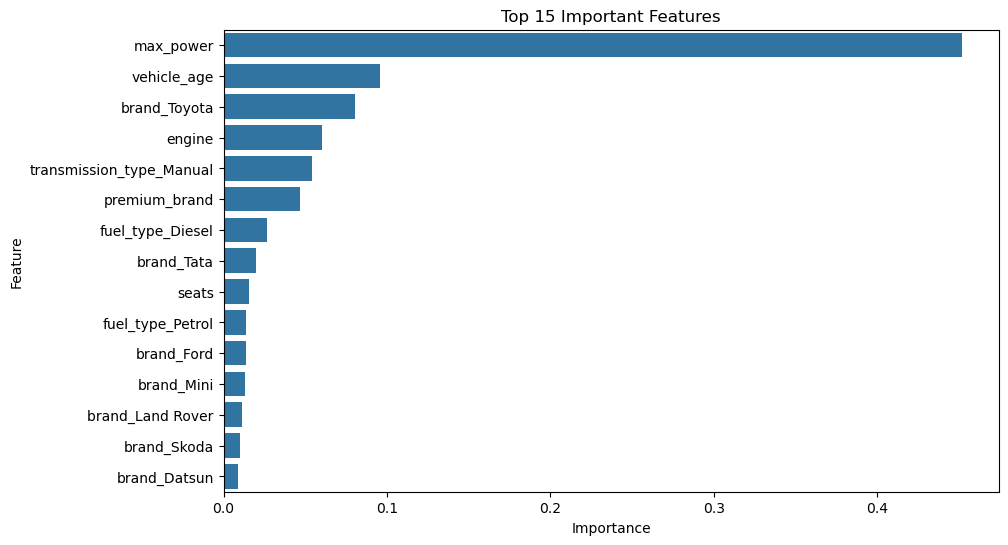

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

# Feature Importance Analysis

The XGBoost model was used to identify the most influential factors affecting used car prices. The results indicate that maximum power is the most important predictor of vehicle resale value, followed by vehicle age, brand reputation, and engine capacity.

Vehicles with higher power output and larger engines generally command higher market prices, while older vehicles experience depreciation and tend to have lower resale values. The analysis also shows that premium brands and certain manufacturers, such as Toyota, have a positive impact on resale value.

# Key Findings
Maximum power is the strongest predictor of selling price.

Vehicle age significantly affects depreciation and resale value.

Engine capacity positively influences vehicle price.

Premium brands retain higher market value.

Brand reputation plays an important role in determining resale prices.

Fuel type and transmission type also contribute to pricing decisions.

# Conclusion
A comprehensive car price prediction system was developed using over 15,000 used vehicle records. After performing data cleaning, exploratory data analysis, feature engineering, and model comparison across five machine learning algorithms, XGBoost achieved the best performance with an R² score of 0.94. Feature importance analysis revealed that maximum power, vehicle age, brand reputation, and engine capacity were the most influential factors affecting resale value.